# Getting started with Qrisp on IQM

Qrisp is a quantum programming language build around the concept of quantum variables. It is designed to be a high-level language that is easy to use and understand. Qrisp is a great tool for beginners to learn quantum computing and for experts to quickly prototype quantum algorithms. It offers a fresh take on quantum programming. You can learn more about Qrisp on the official website: [https://qrisp.eu/](https://qrisp.eu/).


In this notebook, you will learn how to ...
* ... get started with Qrisp.
* ... run a Qrisp program on an IQM backend.
* ... use Qrisp libraries to implement quantum algorithms.


### Installing the necessary packages
In order to get started, make sure you have the appropriate packages installed. Make sure that you install qrisp with the iqm extension.

In [ ]:
%%capture
!pip install qrisp[iqm]
# On some systems, you may need to use quotes around the extras:
#!pip install "qrisp[iqm]"

### Writing a Qrisp program

In order to use Qrisp, you need to import the `qrisp` package. You can do this by running the following code:

In [1]:
from qrisp import *

Qrisp provides advanced quantum data types such as QuantumFloat that we will use in this example. In this example we wil encode a 2 it will multiply it with itself and then measure the result. 

Let's run it on a simulator first.

In [2]:
a = QuantumFloat(2)
a[:] = 2
b = a+a
b.get_measurement()

{4: 1.0}

## Running that circuit on IQM Resonance

Now, let's run that same circuit on IQM Resonance.
In order to access an IQM quantum computer through Qrisp, we will need to create an API Token.You can do this by logging into IQM Resonance at [https://resonance.meetiqm.com/](https://resonance.meetiqm.com/). Once you are logged in, open the side panel to create a new token.

Copy the token, and add it as a parameter `api_token` to the `IQMBackend` function. It is recommended to load it from an environment variable.

In [ ]:
from qrisp.interface import IQMBackend
token = "YOUR_TOKEN"
iqm_emerald = IQMBackend(api_token = token, 
                          device_instance = "emerald:timeslot")

a = QuantumFloat(2)
a[:] = 2
b = a + a
b.get_measurement(backend = iqm_emerald)

{2: 0.554,
 3: 0.101,
 0: 0.073,
 1: 0.07,
 6: 0.055,
 10: 0.045,
 4: 0.027,
 7: 0.015,
 5: 0.012,
 11: 0.011,
 12: 0.009,
 14: 0.009,
 15: 0.007,
 8: 0.006,
 9: 0.003,
 13: 0.003}

We can also set the number of shots as a parameter.

In [ ]:
a = QuantumFloat(2)
a[:] = 1
b = a + a
b.get_measurement(backend = iqm_emerald, shots=2000)

{2: 0.6365,
 0: 0.066,
 3: 0.0595,
 10: 0.047,
 1: 0.035,
 6: 0.033,
 11: 0.023,
 4: 0.018,
 12: 0.0165,
 5: 0.013,
 7: 0.0125,
 8: 0.012,
 14: 0.0095,
 9: 0.0075,
 13: 0.0055,
 15: 0.0055}

## Advanced examples

### The Variational Quantum Eigensolver (VQE) in Qrisp

The **Variational Quantum Eigensolver (VQE)** is a hybrid quantum-classical algorithm designed to find the ground state energy of quantum systems, such as molecules or materials. VQE is especially significant in the era of Noisy Intermediate-Scale Quantum (NISQ) devices, as it is robust to noise and hardware limitations that challenge more demanding quantum algorithms like Quantum Phase Estimation.

At its core, VQE works by defining a problem Hamiltonian $H$—which encodes the physics of the system of interest—and preparing a parameterized quantum state (the *ansatz*) $|\psi(\theta)\rangle = U(\theta)|0\rangle$. The quantum computer evaluates the expectation value $\langle \psi(\theta)| H |\psi(\theta)\rangle$, while a classical optimizer iteratively updates the parameters $\theta$ to minimize this value. The lowest expectation value found approximates the ground state energy of $H$:

$E(\theta) = \langle \psi(\theta)| H |\psi(\theta)\rangle$

This hybrid approach leverages the strengths of both quantum and classical computation: quantum hardware prepares and measures quantum states, while classical routines perform the optimization. VQE has become a cornerstone algorithm for quantum chemistry, enabling the calculation of molecular energies and properties that are classically intractable due to exponential scaling.

The VQE algorithm was first experimentally demonstrated by Alberto Peruzzo, Jarrod McClean, Peter Shadbolt, Man-Hong Yung, Xiao-Qi Zhou, Peter J. Love, Alán Aspuru-Guzik, and Jeremy L. O'Brien in 2014. Their work showed that VQE could calculate the ground state energy of simple molecules, such as $\mathrm{H}_2$, using a quantum processor in conjunction with a classical optimizer.

In Qrisp, the `VQEProblem` class encapsulates the Hamiltonian, ansatz, and optimization process, making it straightforward to set up and solve VQE problems for quantum chemistry and beyond. The example below demonstrates how to use Qrisp to compute the ground state energy of the hydrogen molecule ($\mathrm{H}_2$) using VQE, either via integration with PySCF for chemistry problems or by directly specifying the Hamiltonian in terms of Pauli operators.

The following cell illustrates the use of Qrisp's VQE implementation to explore quantum chemistry problems and demonstrates the synergy between quantum programming and quantum hardware.

In [ ]:

# We use the pyscf library to load chemistry data from arbitrary molecules.
# This library can however only be installed on Linux & Mac systems.
try:
    from pyscf import gto
    from qrisp.operators import FermionicOperator
    mol = gto.M(atom = '''H 0 0 0; H 0 0 0.74''', basis = 'sto-3g')
    H = FermionicOperator.from_pyscf(mol)
    
except ImportError:
    # Specify the problem Hamiltonian "manually" with Pauli Operators
    from qrisp.operators.qubit import X,Y,Z
    c = [-0.81054, 0.16614, 0.16892, 0.17218, -0.22573, 0.12091, 0.166145, 0.04523]
    H = c[0] \
        + c[1]*Z(0)*Z(2) \
        + c[2]*Z(1)*Z(3) \
        + c[3]*(Z(3) + Z(1)) \
        + c[4]*(Z(2) + Z(0)) \
        + c[5]*(Z(2)*Z(3) + Z(0)*Z(1)) \
        + c[6]*(Z(0)*Z(3) + Z(1)*Z(2)) \
        + c[7]*(Y(0)*Y(1)*Y(2)*Y(3) + X(0)*X(1)*Y(2)*Y(3) + Y(0)*Y(1)*X(2)*X(3) + X(0)*X(1)*X(2)*X(3))

# Ansatz
def ansatz(qv,theta):
    for i in range(4):
        ry(theta[i],qv[i])
    for i in range(3):
        cx(qv[i],qv[i+1])
    cx(qv[3],qv[0])

from qrisp.vqe.vqe_problem import *

vqe = VQEProblem(hamiltonian = H,
                 ansatz_function = ansatz,
                 num_params = 4,
                 callback = True)

energy = vqe.run(QuantumVariable(4),
                 depth = 1,
                 max_iter = 50,
                 mes_kwargs = {"backend" : iqm_emerald})
print(energy)
# Yields -1.864179046 

-1.6145403864131591


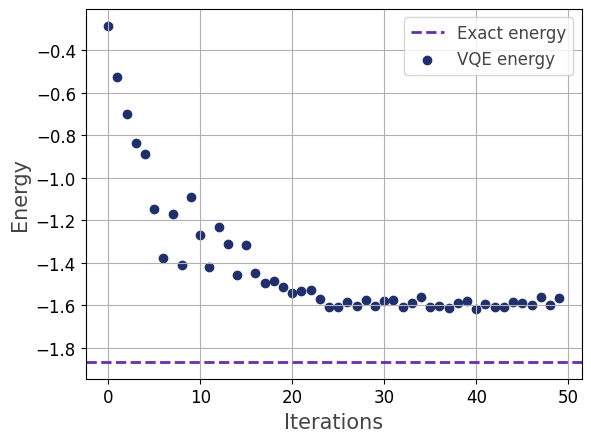

In [6]:
vqe.visualize_energy(exact=True)

## Grover's Algorithm and Its Exact Variant in Qrisp

**Grover's algorithm** is a fundamental quantum algorithm that enables a quadratic speedup for searching an unsorted database. While a classical search requires $O(N)$ queries to find a marked item among $N$ possibilities, Grover's algorithm achieves this in only $O(\sqrt{N})$ queries by amplifying the probability amplitude of the target state through repeated quantum operations. The original algorithm, introduced by Lov K. Grover in 1996, uses phase inversion and "inversion about the average" to boost the likelihood of measuring the correct state, but does not guarantee a $100\%$ success rate after a finite number of iterations.

To address this limitation, the **exact Grover's algorithm** was developed. In this variant, the phase inversion is replaced by a precisely calculated phase rotation, ensuring that the marked state is found with certainty ($100\%$ success rate) after a specific number of iterations. The required rotation angle $\phi$ is analytically determined based on the size of the search space and the number of solutions. This approach was formalized in the paper "Grover Algorithm with zero theoretical failure rate" by G. L. Long, published in *Physical Review A* in 2001. This modification allows the algorithm to reach the solution deterministically, provided the number of target states is known in advance.

In Qrisp, the `grovers_alg` function supports this exact version through the `exact=True` parameter, allowing users to implement and execute Grover's algorithm with zero theoretical failure rate on quantum hardware or simulators. If execute with these parameters, the user also has to specify the expected amount of solutions.

This notebook demonstrates how to use Qrisp to implement **exact Grover's algorithm** and run it on an IQM quantum backend, highlighting the interaction between high-level quantum programming and real quantum hardware.


In [7]:
from qrisp.grover import tag_state, grovers_alg

# Define the oracle
# This oracle tags the state |2>.
def oracle(qv, phase = np.pi):
    tag_state({qv : 2}, phase = phase)

# Define the QuantumFloat representing the search space
n = 3
qf = QuantumFloat(n)

# Execute Grover's algorithm
grovers_alg(qf, 
            oracle, 
            exact = True, 
            winner_state_amount = 1)

# Retrieve the measurements
simulator_res = qf.get_measurement()
print("Simulator result: ", simulator_res)

meas_res = qf.get_measurement(backend = iqm_emerald)
print("Emerald result: ", meas_res)

Simulator result:  {2: 1.0}                                                          
Emerald result:  {2: 0.464, 6: 0.103, 0: 0.092, 7: 0.085, 3: 0.073, 5: 0.071, 1: 0.056, 4: 0.056}


## References

- Qrisp Documentation: [Variational Quantum Eigensolver](https://qrisp.eu/reference/Algorithms/vqe/VQE.html)
- A. Peruzzo, J. McClean, P. Shadbolt, M.-H. Yung, X.-Q. Zhou, P. J. Love, A. Aspuru-Guzik, J. L. O'Brien, "A variational eigenvalue solver on a quantum processor," *Nature Communications* 5, 4213 (2014), arXiv:1304.3061[2][5]
- G. L. Long, "Grover Algorithm with zero theoretical failure rate," *Phys. Rev. A* 64, 022307 (2001). [arXiv:quant-ph/0106071][1]
- L. K. Grover, "A fast quantum mechanical algorithm for database search," *Proceedings, 28th Annual ACM Symposium on the Theory of Computing (STOC)*, 1996. [arXiv:quant-ph/9605043]

In [ ]:

# Copyright 2025 IQM Quantum Computers (Raphael Seidel, Stefan Seegerer)
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.